<a href="https://colab.research.google.com/github/RitikaTholia/Gold-Price-Forecasting/blob/main/Hybrid_Machine_Learning_Framework_for_Gold_Price_Forecasting_Using_Macroeconomic_and_Technical_Indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Hybrid Machine Learning Framework for Gold Price Forecasting Using Macroeconomic and Technical Indicators**

## Goal of the Project

The primary objective of this project is to develop a hybrid financial forecasting framework capable of predicting gold price movements using machine learning and deep learning techniques.

The project combines historical gold prices with macroeconomic and market indicators such as silver prices, crude oil prices, stock market indices, volatility indices, and treasury yields to study their influence on gold price behavior.

This project aims to:

- Analyze relationships between gold prices and economic indicators
- Perform financial time-series forecasting using AI/ML models
- Compare traditional machine learning and deep learning approaches
- Apply feature engineering and technical analysis indicators
- Interpret model behavior using explainable AI techniques

The system is designed as an experimental research-oriented forecasting framework rather than a guaranteed financial prediction system.

## Importance of Gold Forecasting

Gold is one of the most significant financial assets in the global economy and is widely considered a safe-haven investment during periods of economic uncertainty, inflation, and geopolitical instability.

Accurate forecasting of gold prices is important for:

- Investors and portfolio managers
- Financial analysts
- Commodity traders
- Risk management systems
- Economic policy analysis

Gold prices are influenced by several interconnected factors including inflation, interest rates, currency strength, crude oil prices, stock market performance, and market volatility.

Because of these complex relationships, gold price forecasting represents a challenging and valuable application of machine learning and financial data analysis.

## Limitations

Financial markets are highly dynamic, nonlinear, and influenced by unpredictable global events such as geopolitical conflicts, economic crises, government policies, and investor sentiment.

The limitations of this project include:

- Historical data may not fully represent future market behavior
- Sudden market shocks cannot be reliably predicted
- Financial time-series data is noisy and non-stationary
- Machine learning models may overfit historical trends
- External real-world factors may not be completely captured by selected indicators
- Forecast accuracy may decrease during periods of extreme volatility

Therefore, this project should be viewed as an experimental forecasting and analytical system rather than a financial decision-making tool.

## Library Installation

The following libraries are required for financial data collection, technical indicator generation, machine learning modeling, deep learning experimentation, visualization, and explainable AI analysis.

In [ ]:
!pip install yfinance ta xgboost shap

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=33aef9a6896b6af77a55633f839a04d7327eb5cea31fa8736a840e91669874a5
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


## Importing Required Libraries

This section imports the core Python libraries used throughout the project.

The imported libraries are used for:
- Data manipulation and preprocessing
- Financial market data collection
- Numerical computations
- Data visualization
- Machine learning and forecasting

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
print("libraries loaded successfully")

libraries loaded successfully


## Explanation of Libraries

### Pandas
Pandas is used for data manipulation, preprocessing, and handling time-series financial datasets using DataFrames.

### NumPy
NumPy is used for numerical operations, array computations, mathematical transformations, and statistical calculations.

### yfinance
yfinance is used to download historical financial market data directly from Yahoo Finance, including gold prices and macroeconomic indicators.

### Matplotlib
Matplotlib is used for data visualization, trend analysis, and plotting time-series graphs.

### ta
The ta (Technical Analysis) library is used to generate financial technical indicators such as moving averages, RSI, MACD, Bollinger Bands, and volatility indicators.

### XGBoost
XGBoost is an advanced machine learning algorithm based on gradient boosting decision trees and is widely used for structured and financial data prediction tasks.

### SHAP
SHAP (SHapley Additive exPlanations) is used for explainable AI analysis to understand how different features influence model predictions.

---



## Dataset and Financial Indicator Selection

In financial forecasting problems, relying only on historical gold prices may not capture the broader economic and market conditions affecting gold price movements. Therefore, this project adopts a multivariate time-series forecasting approach by integrating multiple financial and macroeconomic indicators.

The selected indicators are chosen based on their economic relationship with gold prices and their influence on investor behavior, inflation expectations, currency strength, and market sentiment.

The dataset consists of historical market data collected from Yahoo Finance using the `yfinance` library.

## Selected Financial Indicators

The following assets and indicators are included in this project:

| Indicator | Ticker | Purpose |
|------------|---------|----------|
| Gold Futures | GC=F | Target variable to forecast gold prices |
| Silver Futures | SI=F | Closely related precious metal often correlated with gold |
| Crude Oil Futures | CL=F | Represents inflationary and economic pressure |
| S&P 500 Index | ^GSPC | Measures stock market performance and investor sentiment |
| US Dollar Index | DX-Y.NYB | Gold prices often move inversely to the US dollar |
| Volatility Index (VIX) | ^VIX | Represents market fear and uncertainty |
| US Treasury Yield | ^TNX | Interest rates influence gold investment demand |

---



## Why These Indicators Were Selected

### Gold Futures (GC=F)
Gold futures prices serve as the primary target variable of the forecasting system. Gold is widely considered a safe-haven asset and is heavily influenced by macroeconomic conditions.

### Silver Futures (SI=F)
Silver often exhibits strong correlation with gold because both are precious metals used as investment assets and inflation hedges.

### Crude Oil Futures (CL=F)
Oil prices can influence inflation expectations and global economic conditions, both of which impact gold demand and pricing.

### S&P 500 Index (^GSPC)
The stock market reflects investor confidence and risk appetite. During periods of stock market uncertainty, investors may shift toward gold as a safer asset.

### US Dollar Index (DX-Y.NYB)
Gold prices frequently demonstrate an inverse relationship with the US dollar. A stronger dollar can reduce gold demand internationally.

### Volatility Index (VIX)
The VIX index measures expected market volatility and investor fear. During periods of high uncertainty, gold demand often increases.

### US Treasury Yield (^TNX)
Treasury yields represent interest rate expectations. Higher yields can reduce the attractiveness of non-interest-bearing assets such as gold.

---



## Multivariate Forecasting Approach

This project uses a multivariate forecasting framework rather than a univariate forecasting approach.

### Univariate Forecasting
Uses only historical gold prices to predict future prices.

### Multivariate Forecasting
Uses gold prices along with additional economic and financial indicators to improve predictive capability and capture broader market dynamics.

The multivariate approach is expected to provide richer contextual information to machine learning and deep learning models.

## Financial Data Collection

In this section, historical financial market data is collected using the `yfinance` library.

The project retrieves daily closing prices for gold and selected macroeconomic indicators from 2015 to 2025. The closing price is used because it represents the final market valuation of an asset for each trading day.

The collected data will later be used for:
- Time-series analysis
- Feature engineering
- Machine learning modeling
- Deep learning forecasting

In [ ]:
assets = {
    'Gold': 'GC=F',
    'Silver': 'SI=F',
    'Oil': 'CL=F',
    'SP500': '^GSPC',
    'USD_Index': 'DX-Y.NYB',
    'VIX': '^VIX',
    'Treasury_Yield': '^TNX'
}

data = pd.DataFrame()

for name, ticker in assets.items():
    df = yf.download(ticker, start='2015-01-01', end='2025-01-01')
    data[name] = df['Close']

data.head()

/tmp/ipykernel_3660/3463746372.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3660/3463746372.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3660/3463746372.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3660/3463746372.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


,Gold,Silver,Oil,SP500,USD_Index,VIX,Treasury_Yield
Date,,,,,,,
2015-01-02,1186.000000,15.734000,52.689999,2058.199951,91.080002,17.790001,2.123
2015-01-05,1203.900024,16.179001,50.040001,2020.579956,91.379997,19.920000,2.039
2015-01-06,1219.300049,16.603001,47.930000,2002.609985,91.500000,21.120001,1.963
2015-01-07,1210.599976,16.510000,48.650002,2025.900024,91.889999,19.309999,1.954
2015-01-08,1208.400024,16.351000,48.790001,2062.139893,92.370003,17.010000,2.016


## Observations from Initial Data Collection

The financial datasets were successfully collected and merged into a unified multivariate time-series dataframe indexed by trading date.

Each row in the dataset represents one trading day and contains:
- Gold prices
- Silver prices
- Oil prices
- S&P 500 values
- US Dollar Index values
- VIX values
- Treasury yields

The collected data appears to be properly aligned chronologically and will be further inspected for:
- Missing values
- Data consistency
- Statistical properties
- Correlation patterns

This combined dataset forms the foundation for subsequent preprocessing, feature engineering, and forecasting tasks.

## Data Inspection and Quality Analysis

Before building forecasting models, it is important to inspect the dataset for:
- Missing values
- Incorrect data types
- Dataset dimensions
- Statistical properties
- Potential inconsistencies

Financial datasets often contain missing observations due to:
- Different trading holidays
- Market closures
- Incomplete records
- Asset-specific trading schedules

Proper data inspection ensures reliability and consistency before feature engineering and modeling.

Dataset Shape

In [ ]:
print("Dataset Shape:")
print(data.shape)

Dataset Shape:
(2513, 7)


Check Missing Values

In [ ]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
Gold              0
Silver            0
Oil               0
SP500             0
USD_Index         0
VIX               0
Treasury_Yield    0
dtype: int64


Data Types

In [ ]:
print("Data Types:")
print(data.dtypes)

Data Types:
Gold              float64
Silver            float64
Oil               float64
SP500             float64
USD_Index         float64
VIX               float64
Treasury_Yield    float64
dtype: object


Statistical Summary

In [ ]:
data.describe()

,Gold,Silver,Oil,SP500,USD_Index,VIX,Treasury_Yield
count,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000
mean,1603.429008,20.089455,62.000036,3357.273701,98.072599,18.274075,2.478031
std,393.086308,4.769146,18.119689,1083.976977,4.903545,7.285308,1.055937
min,1050.800049,11.735000,-37.630001,1829.079956,88.589996,9.140000,0.499000
25%,1262.199951,16.289000,48.520000,2432.540039,94.510002,13.340000,1.728000
50%,1526.599976,18.041000,59.939999,3005.699951,97.250000,16.330000,2.319000
75%,1870.199951,23.853001,74.040001,4205.450195,101.809998,21.330000,3.110000
max,2788.500000,34.831001,123.699997,6090.270020,114.110001,82.690002,4.988000


## Initial Dataset Observations

The dataset appears to be clean and well-structured with:
- 2513 trading-day observations
- 7 financial and macroeconomic indicators
- No missing values
- Consistent numerical data types across all variables

Several important observations can already be identified:

- Gold prices show substantial long-term variation, indicating changing macroeconomic conditions over the selected period.
- The S&P 500 index exhibits the largest absolute scale among the variables.
- The VIX index demonstrates strong volatility spikes, reflecting periods of market fear and uncertainty.
- Crude oil prices contain extreme fluctuations, including negative values during the 2020 COVID-19 market disruption.
- Treasury yields vary significantly over time, indicating changing interest rate environments.

The differences in scale and volatility across variables suggest that feature scaling and normalization may become important during machine learning and deep learning modeling stages.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to better understand:
- Historical trends
- Statistical behavior
- Relationships between variables
- Volatility patterns
- Potential predictive signals

EDA is an important stage in financial machine learning because financial markets are highly dynamic and often exhibit nonlinear and time-dependent behavior.

The insights obtained during this stage help guide:
- Feature engineering
- Model selection
- Forecasting strategies
- Risk analysis

## Time-Series Visualization of Financial Indicators

Visualizing historical financial indicators is an important step in understanding:
- Long-term market trends
- Volatility patterns
- Structural market changes
- Economic disruptions
- Potential relationships between variables

Since this project focuses on financial time-series forecasting, plotting each variable over time helps identify:
- Trend behavior
- Market crashes
- Periods of high volatility
- Regime changes
- Anomalous events

These insights are important for selecting forecasting techniques and designing meaningful features for machine learning models.

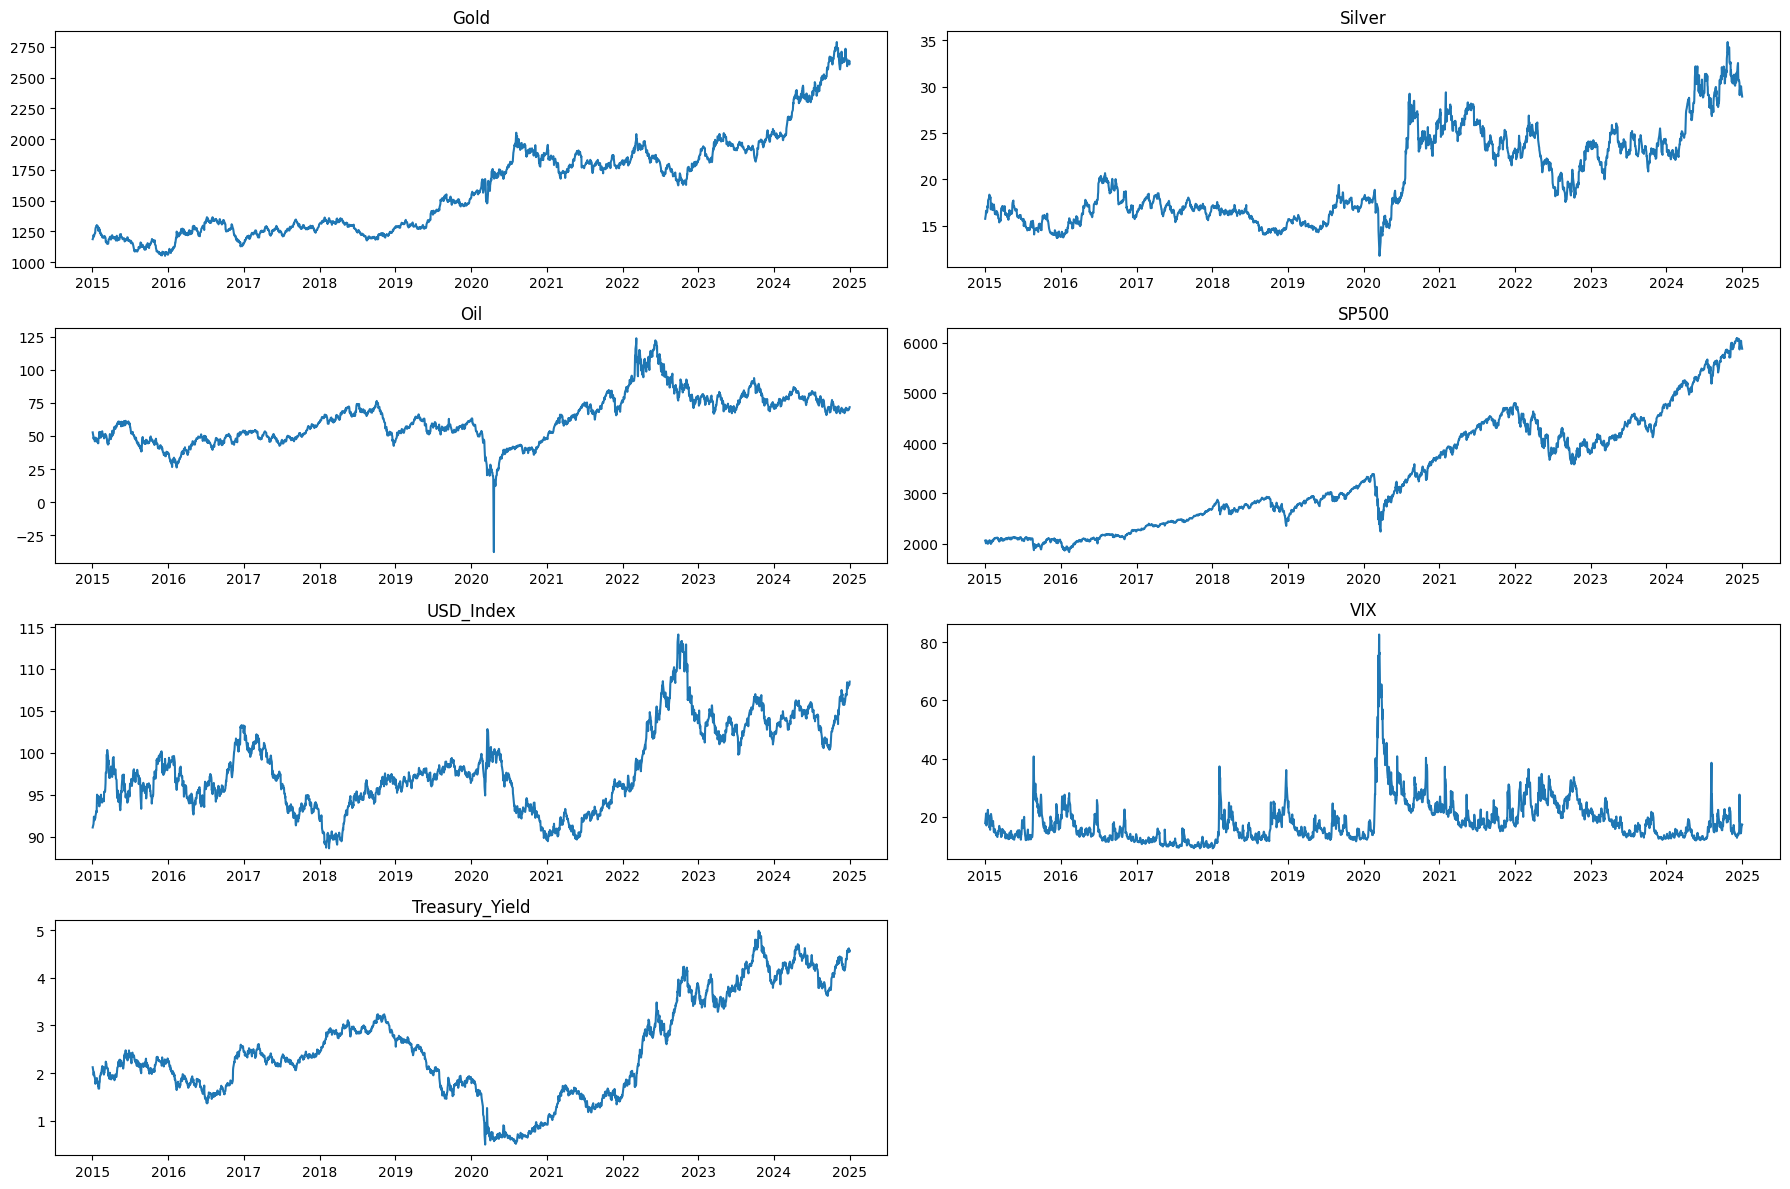

In [ ]:
plt.figure(figsize=(18,12))

for i, column in enumerate(data.columns, 1):
    plt.subplot(4, 2, i)
    plt.plot(data.index, data[column])
    plt.title(column)
    plt.tight_layout()

plt.show()

## Observations from Time-Series Visualization

Several important financial patterns can be observed from the plotted indicators:

### Gold Prices
Gold prices show a strong long-term upward trend, especially after 2019, indicating increased investor demand during periods of economic uncertainty and inflationary pressure.

### Silver Prices
Silver demonstrates behavior similar to gold, supporting the hypothesis that precious metals may share correlated market dynamics.

### Crude Oil Prices
Oil prices exhibit extreme volatility, including a significant negative price event during the COVID-19 crisis in 2020. This highlights the presence of rare financial anomalies in market data.

### S&P 500 Index
The S&P 500 displays strong long-term growth with visible market corrections and recovery phases, particularly during the COVID-19 market crash.

### US Dollar Index
The dollar index shows cyclical movement and periods of strengthening and weakening currency behavior that may influence gold prices.

### VIX (Volatility Index)
The VIX demonstrates sharp spikes during periods of market stress and uncertainty, especially during major financial disruptions.

### Treasury Yields
Treasury yields exhibit changing interest-rate environments over time, which may affect investor preference toward gold as a non-interest-bearing asset.

Overall, the visualizations confirm that the dataset captures multiple market regimes, economic cycles, and volatility patterns relevant to financial forecasting.

## Correlation Matrix Analysis

Correlation analysis is performed to measure the linear relationships between financial variables.

In financial forecasting, correlation analysis helps:
- Identify potentially influential indicators
- Understand market relationships
- Support feature selection
- Detect redundant variables

The correlation coefficient ranges from:
- +1 → strong positive relationship
- -1 → strong negative relationship
- 0 → little or no linear relationship

Although correlation does not imply causation, it provides useful preliminary insight into how financial variables move relative to each other.

In [ ]:
correlation_matrix = data.corr()

correlation_matrix

,Gold,Silver,Oil,SP500,USD_Index,VIX,Treasury_Yield
Gold,1.000000,0.918320,0.509979,0.942912,0.447087,0.206266,0.408374
Silver,0.918320,1.000000,0.479355,0.872309,0.247173,0.064515,0.293608
Oil,0.509979,0.479355,1.000000,0.672677,0.460752,-0.048148,0.612213
SP500,0.942912,0.872309,0.672677,1.000000,0.447669,0.082898,0.500961
USD_Index,0.447087,0.247173,0.460752,0.447669,1.000000,0.093278,0.694751
VIX,0.206266,0.064515,-0.048148,0.082898,0.093278,1.000000,-0.273544
Treasury_Yield,0.408374,0.293608,0.612213,0.500961,0.694751,-0.273544,1.000000


## Observations from Correlation Analysis

Several meaningful relationships can be observed from the correlation matrix:

### Gold and Silver
Gold and silver exhibit a very strong positive correlation (0.92), indicating that both precious metals often move together under similar market conditions.

### Gold and S&P 500
Gold shows a strong positive correlation with the S&P 500 index (0.94) over the selected period. This may reflect broader long-term macroeconomic growth trends captured in the dataset.

### Oil and Treasury Yields
Oil prices and treasury yields demonstrate moderate positive correlation, potentially reflecting inflationary and economic growth relationships.

### VIX Relationships
The VIX index generally shows weaker or negative correlations with other variables, consistent with its role as a market fear and uncertainty indicator.

### USD Index
The US Dollar Index demonstrates moderate relationships with several variables. Currency strength often influences commodity pricing and investor behavior.

The correlation analysis suggests that multiple indicators may contain predictive information relevant to gold price forecasting. However, these relationships may evolve over time due to changing market conditions and economic regimes.

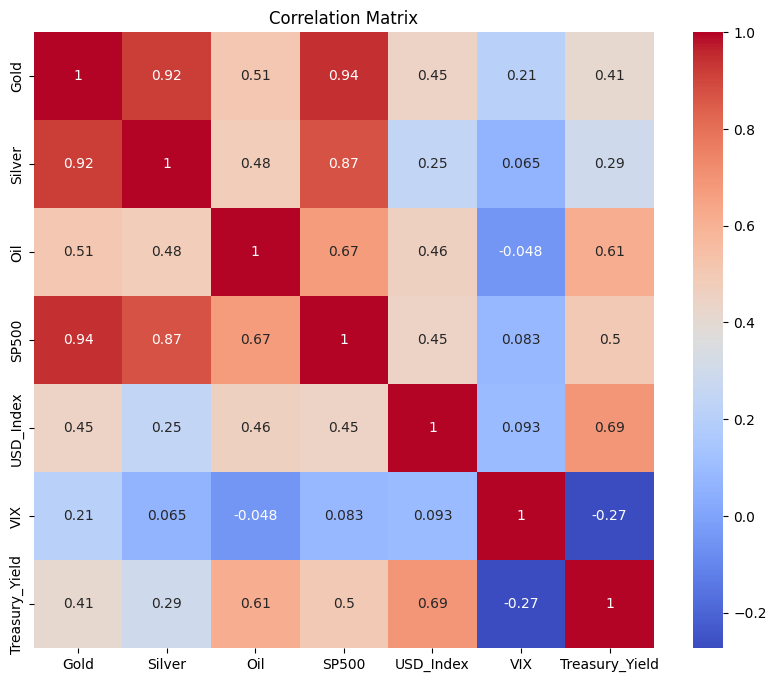

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

> ## Important Research Insight
>
> Financial time-series data often contains:
> - Spurious correlations
> - Regime-dependent relationships
> - Non-stationary behavior
>
> Raw asset prices may produce misleadingly strong correlations because many financial assets exhibit long-term upward or downward trends over time.
>
> For example, gold prices and the S&P 500 index show strong positive correlation in the dataset. However, this does not necessarily imply a direct causal relationship between the two assets.
>
> Such correlations may emerge due to:
> - Shared long-term macroeconomic trends
> - Inflationary environments
> - Global liquidity conditions
> - Time-dependent market regimes
>
> This highlights why advanced financial forecasting systems often rely on:
> - Feature engineering
> - Rolling statistics
> - Returns instead of raw prices
> - Differencing techniques
> - Time-window analysis
>
> These methods help models capture dynamic market behavior more effectively while reducing the risk of learning misleading relationships from raw financial data.

---



# Feature Engineering

Feature engineering is one of the most important stages in financial machine learning and time-series forecasting.

Raw financial prices often contain limited predictive information when used directly. Therefore, additional derived features are created to help machine learning models better capture:
- Market trends
- Momentum
- Volatility
- Price dynamics
- Temporal dependencies

This project applies both statistical and technical-analysis-based feature engineering techniques to transform raw market data into more informative predictive signals.

The engineered features include:
- Daily returns
- Moving averages
- Rolling volatility
- Relative Strength Index (RSI)
- Lagged price features
- MACD indicators
- Bollinger Bands

These features are commonly used in quantitative finance and algorithmic trading systems.





## Daily Returns

Financial forecasting models often use percentage returns instead of raw prices because returns provide:
- Better stationarity
- Relative price movement information
- Reduced trend bias
- Improved comparability across assets

Daily return measures the percentage change in price from one trading day to the next.

In [ ]:
returns = data.pct_change()

returns.head()

,Gold,Silver,Oil,SP500,USD_Index,VIX,Treasury_Yield
Date,,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,0.015093,0.028283,-0.050294,-0.018278,0.003294,0.119730,-0.039567
2015-01-06,0.012792,0.026207,-0.042166,-0.008893,0.001313,0.060241,-0.037273
2015-01-07,-0.007135,-0.005601,0.015022,0.011630,0.004262,-0.085701,-0.004585
2015-01-08,-0.001817,-0.009631,0.002878,0.017888,0.005224,-0.119109,0.031730


## Observations from Daily Returns

The daily returns dataset represents percentage price changes between consecutive trading days.

Several important observations can be made:

- The first row contains NaN values because return calculation requires a previous trading day's price.
- Returns fluctuate around relatively small values compared to raw prices.
- Positive values indicate price increases, while negative values indicate price declines.
- Return-based representations help reduce long-term trend effects commonly present in raw financial prices.

Compared to raw prices, returns often provide:
- Better statistical stability
- Improved stationarity
- Enhanced modeling suitability for financial forecasting systems

Returns are widely used in quantitative finance because they focus on relative market movement rather than absolute asset prices.

## Why Returns Are Important

Raw financial prices are often non-stationary because they contain long-term trends and changing market regimes.

Returns help reduce these effects by focusing on relative price movement rather than absolute price levels.

Using returns instead of raw prices can help machine learning models:
- Learn short-term market behavior
- Reduce misleading trend effects
- Improve statistical stability
- Better capture volatility dynamics

Returns are widely used in:
- Quantitative finance
- Portfolio optimization
- Risk analysis
- Algorithmic trading systems

---



## Technical Indicator Generation

Technical indicators are mathematical transformations of historical price data used to analyze:
- Trend direction
- Momentum
- Volatility
- Market strength

These indicators are commonly used in:
- Quantitative finance
- Technical analysis
- Algorithmic trading
- Financial forecasting systems

In this project, technical indicators are used as engineered features for machine learning and deep learning models.

In [ ]:
import ta

## Engineered Technical Features

### Simple Moving Average (SMA)
Moving averages smooth short-term fluctuations and help identify long-term trends.

- SMA 10 captures shorter-term market movement
- SMA 30 captures broader trend behavior

### Relative Strength Index (RSI)
RSI measures momentum and identifies potential overbought or oversold conditions.

Typical interpretation:
- RSI > 70 → overbought
- RSI < 30 → oversold

### MACD (Moving Average Convergence Divergence)
MACD is a momentum indicator that measures the relationship between short-term and long-term moving averages.

It is commonly used to identify:
- Trend reversals
- Momentum changes
- Bullish or bearish signals

### Rolling Volatility
Rolling volatility measures the variability of gold prices over a moving window.

High volatility often indicates:
- Increased uncertainty
- Market stress
- Larger price fluctuations

In [ ]:
feature_data = data.copy()

# Moving Averages
feature_data['Gold_SMA_10'] = ta.trend.sma_indicator(feature_data['Gold'], window=10)
feature_data['Gold_SMA_30'] = ta.trend.sma_indicator(feature_data['Gold'], window=30)

# RSI
feature_data['Gold_RSI'] = ta.momentum.rsi(feature_data['Gold'], window=14)

# MACD
feature_data['Gold_MACD'] = ta.trend.macd(feature_data['Gold'])

# Volatility
feature_data['Gold_Volatility'] = feature_data['Gold'].rolling(window=10).std()

feature_data.head()

,Gold,Silver,Oil,SP500,USD_Index,VIX,Treasury_Yield,Gold_SMA_10,Gold_SMA_30,Gold_RSI,Gold_MACD,Gold_Volatility
Date,,,,,,,,,,,,
2015-01-02,1186.000000,15.734000,52.689999,2058.199951,91.080002,17.790001,2.123,NaN,NaN,NaN,NaN,NaN
2015-01-05,1203.900024,16.179001,50.040001,2020.579956,91.379997,19.920000,2.039,NaN,NaN,NaN,NaN,NaN
2015-01-06,1219.300049,16.603001,47.930000,2002.609985,91.500000,21.120001,1.963,NaN,NaN,NaN,NaN,NaN
2015-01-07,1210.599976,16.510000,48.650002,2025.900024,91.889999,19.309999,1.954,NaN,NaN,NaN,NaN,NaN
2015-01-08,1208.400024,16.351000,48.790001,2062.139893,92.370003,17.010000,2.016,NaN,NaN,NaN,NaN,NaN


## Observations from Technical Feature Generation

Additional technical-analysis-based features were successfully generated for the gold price series.

These engineered indicators help transform raw price data into more informative representations of:
- Trend behavior
- Momentum
- Volatility
- Market dynamics

Several NaN values appear in the initial rows of the dataset. This occurs because rolling-window indicators require sufficient historical observations before values can be computed.

For example:
- SMA 10 requires at least 10 historical prices
- SMA 30 requires at least 30 observations
- RSI requires a rolling calculation window
- Volatility measures depend on rolling standard deviation calculations

This behavior is expected and commonly occurs in time-series forecasting pipelines.

> ## Important Time-Series Insight
>
> Many financial indicators depend on historical rolling windows rather than single observations.
>
> Unlike traditional tabular datasets, time-series forecasting systems must preserve chronological structure because future information cannot be used to compute past values.
>
> This introduces several important preprocessing challenges:
> - Rolling-window NaN values
> - Temporal dependencies
> - Sequential feature generation
> - Data leakage prevention
>
> Proper handling of these issues is critical for building reliable forecasting systems.

## Handling Missing Values After Feature Engineering

The engineered technical indicators introduced missing values at the beginning of the dataset due to rolling-window calculations.

Since these missing observations occur only in the initial rows and represent unavailable historical context rather than corrupted data, the rows will be removed before model training.

This ensures that all machine learning models receive complete numerical feature inputs.

In [ ]:
feature_data.dropna(inplace=True)

feature_data.head()

,Gold,Silver,Oil,SP500,USD_Index,VIX,Treasury_Yield,Gold_SMA_10,Gold_SMA_30,Gold_RSI,Gold_MACD,Gold_Volatility
Date,,,,,,,,,,,,
2015-02-13,1226.500000,17.278,52.779999,2096.989990,94.199997,14.69,2.021,1243.359998,1249.736662,43.211361,-1.436645,20.449782
2015-02-17,1208.099976,16.362,53.529999,2100.340088,94.059998,15.80,2.145,1236.550000,1250.473328,37.535378,-4.035230,19.620817
2015-02-18,1199.699951,16.250,52.139999,2099.679932,94.199997,15.45,2.066,1230.550000,1250.333325,35.258431,-6.695260,20.888045
2015-02-19,1207.099976,16.371,51.160000,2097.449951,94.400002,15.29,2.113,1224.879993,1249.926656,38.781584,-8.112714,18.407855
2015-02-20,1204.400024,16.263,50.340000,2110.300049,94.250000,14.30,2.133,1219.119995,1249.719991,37.969702,-9.346183,13.981736


In [ ]:
print("Feature Dataset Shape:")
print(feature_data.shape)

Feature Dataset Shape:
(2484, 12)


## Effect of Feature Engineering on Dataset Dimensions

After technical feature generation and missing-value handling:
- The number of columns increased from 7 to 12
- The number of rows decreased slightly due to rolling-window calculations

The additional columns represent engineered financial indicators designed to provide richer predictive information to machine learning models.

The reduction in rows occurred because rolling indicators such as moving averages and RSI require sufficient historical observations before valid values can be computed.

For example:
- SMA 30 requires at least 30 trading days
- Rolling volatility requires historical windows
- MACD depends on moving-average calculations

As a result, the initial rows containing incomplete indicator calculations were removed to ensure clean numerical inputs for downstream forecasting models.

---



> ## Methodological Note
>
> The feature engineering pipeline preserves chronological integrity by ensuring that all engineered indicators and lag features are computed using only historical observations.
>
> This is important in financial forecasting because using future information during training would introduce data leakage and produce unrealistically optimistic model performance.
>
> Maintaining temporal consistency is a critical requirement in time-series machine learning systems.

---



## Lag Feature Engineering

Lag features are created to provide historical memory to forecasting models.

A lag feature represents the value of a variable from a previous time step. These features help machine learning models learn temporal dependencies and sequential market behavior.

In financial forecasting, previous price information often contains important signals regarding:
- Momentum
- Trend continuation
- Market reversals
- Short-term temporal dynamics

Lag-based modeling is widely used in:
- Time-series forecasting
- Quantitative finance
- Algorithmic trading
- Deep learning sequence models

In [ ]:
feature_data['Gold_Lag_1'] = feature_data['Gold'].shift(1)
feature_data['Gold_Lag_2'] = feature_data['Gold'].shift(2)
feature_data['Gold_Lag_3'] = feature_data['Gold'].shift(3)

feature_data.head()

,Gold,Silver,Oil,SP500,USD_Index,VIX,Treasury_Yield,Gold_SMA_10,Gold_SMA_30,Gold_RSI,Gold_MACD,Gold_Volatility,Gold_Lag_1,Gold_Lag_2,Gold_Lag_3
Date,,,,,,,,,,,,,,,
2015-02-13,1226.500000,17.278,52.779999,2096.989990,94.199997,14.69,2.021,1243.359998,1249.736662,43.211361,-1.436645,20.449782,NaN,NaN,NaN
2015-02-17,1208.099976,16.362,53.529999,2100.340088,94.059998,15.80,2.145,1236.550000,1250.473328,37.535378,-4.035230,19.620817,1226.500000,NaN,NaN
2015-02-18,1199.699951,16.250,52.139999,2099.679932,94.199997,15.45,2.066,1230.550000,1250.333325,35.258431,-6.695260,20.888045,1208.099976,1226.500000,NaN
2015-02-19,1207.099976,16.371,51.160000,2097.449951,94.400002,15.29,2.113,1224.879993,1249.926656,38.781584,-8.112714,18.407855,1199.699951,1208.099976,1226.500000
2015-02-20,1204.400024,16.263,50.340000,2110.300049,94.250000,14.30,2.133,1219.119995,1249.719991,37.969702,-9.346183,13.981736,1207.099976,1199.699951,1208.099976


## Understanding Lag Features

Lag features store historical values from previous time steps.

Examples:
- Gold_Lag_1 → gold price from 1 day earlier
- Gold_Lag_2 → gold price from 2 days earlier
- Gold_Lag_3 → gold price from 3 days earlier

These features allow forecasting models to incorporate recent historical context when generating predictions.

Lag features are particularly important in financial forecasting because market behavior often exhibits short-term temporal dependencies and momentum effects.

In [ ]:
feature_data.dropna(inplace=True)

print(feature_data.shape)

(2481, 15)


## Final Engineered Dataset

After generating technical indicators and lag features, the dataset now contains:
- 2481 trading-day observations
- 15 engineered financial features

The final feature set includes:
- Original macroeconomic indicators
- Technical analysis indicators
- Rolling volatility measures
- Temporal lag features

These engineered variables provide machine learning models with:
- Trend information
- Momentum behavior
- Volatility dynamics
- Historical market memory

The dataset is now sufficiently enriched for machine learning and deep learning forecasting tasks.

---



# Machine Learning Dataset Preparation

Before training forecasting models, the engineered dataset must be transformed into a machine-learning-ready format.

This stage includes:
- Selecting the target variable
- Separating input features and prediction targets
- Scaling numerical features
- Splitting training and testing datasets chronologically

In time-series forecasting, maintaining chronological order is extremely important because future observations must never influence past training data.

Improper splitting can introduce data leakage and produce misleadingly optimistic forecasting performance.

---



## Target Variable Construction

The forecasting objective of this project is to predict future gold prices using historical financial and macroeconomic information.

To achieve this, the target variable is defined as the next trading day's gold price.

This transforms the problem into a supervised machine learning forecasting task where:
- Input features represent current market conditions
- Target values represent future gold prices

---



In [ ]:
feature_data['Target'] = feature_data['Gold'].shift(-1)

feature_data.tail()

,Gold,Silver,Oil,SP500,USD_Index,VIX,Treasury_Yield,Gold_SMA_10,Gold_SMA_30,Gold_RSI,Gold_MACD,Gold_Volatility,Gold_Lag_1,Gold_Lag_2,Gold_Lag_3,Target
Date,,,,,,,,,,,,,,,,
2024-12-24,2620.000000,29.974001,70.099998,6040.040039,108.260002,14.27,4.591,2646.279980,2638.016667,45.646373,-9.144972,40.356340,2612.300049,2628.699951,2592.199951,2638.800049
2024-12-26,2638.800049,30.047001,69.620003,6037.589844,108.129997,14.73,4.579,2636.779980,2639.310002,48.855933,-8.295974,26.143609,2620.000000,2612.300049,2628.699951,2617.199951
2024-12-27,2617.199951,29.655001,70.599998,5970.839844,108.000000,15.95,4.619,2629.749976,2640.523332,45.529411,-9.259349,19.630028,2638.800049,2620.000000,2612.300049,2606.100098
2024-12-30,2606.100098,29.106001,70.989998,5906.939941,108.129997,17.40,4.545,2624.759985,2641.786670,43.876126,-10.794069,18.527142,2617.199951,2638.800049,2620.000000,2629.199951
2024-12-31,2629.199951,28.940001,71.720001,5881.629883,108.489998,17.35,4.573,2622.539990,2643.903337,48.099898,-10.030752,16.159068,2606.100098,2617.199951,2638.800049,NaN


In [ ]:
feature_data.dropna(inplace=True)

print(feature_data.shape)

(2480, 16)


## Feature Matrix and Target Separation

The dataset is separated into:
- Input feature matrix (X)
- Prediction target vector (y)

The feature matrix contains:
- Macroeconomic indicators
- Technical indicators
- Lag-based temporal features

The target vector contains the future gold price to be predicted by forecasting models.

In [ ]:
X = feature_data.drop('Target', axis=1)

y = feature_data['Target']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2480, 15)
Target Shape: (2480,)


## Final Supervised Forecasting Dataset

The final dataset has been successfully transformed into a supervised machine learning forecasting structure.

Dataset dimensions:
- Feature matrix shape: (2480, 15)
- Target vector shape: (2480,)

The feature matrix contains:
- Original financial indicators
- Technical-analysis-based features
- Rolling volatility measures
- Historical lag features

The target variable represents the next trading day's gold price.

This transformation enables machine learning models to learn relationships between current market conditions and future gold price behavior.

---



## Feature Scaling

Financial indicators often exist on very different numerical scales.

Examples:
- S&P 500 values may exceed 5000
- RSI values typically range between 0 and 100
- Treasury yields are often below 5

Large differences in feature magnitude can negatively affect machine learning training dynamics and optimization stability.

Therefore, feature scaling is applied to normalize feature distributions before model training.

This project uses StandardScaler, which transforms features to have:
- Mean ≈ 0
- Standard deviation ≈ 1

In [ ]:
from sklearn.preprocessing import StandardScaler

## Chronological Train-Test Split

Unlike traditional machine learning problems, time-series forecasting requires preserving chronological order.

Random splitting is avoided because future observations must not influence past training data.

The dataset is therefore divided chronologically:
- Earlier observations → training set
- Later observations → testing set

This better simulates real-world forecasting conditions.

In [ ]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (1984, 15)
Testing Set Shape: (496, 15)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

> ## Important Machine Learning Insight
>
> Feature scaling was performed using statistics derived only from the training dataset.
>
> This is important because scaling the entire dataset before splitting would introduce data leakage, allowing future information from the testing period to influence the training process.
>
> Preventing data leakage is critical in financial forecasting because even small leakage can produce unrealistically optimistic model performance.

---



# Baseline Machine Learning Model

A baseline model is important in machine learning because it provides a reference point for evaluating more advanced forecasting systems.

This project first applies Linear Regression as a simple baseline forecasting model.

Linear Regression attempts to model the relationship between financial indicators and future gold prices using a linear mathematical relationship.

Although financial markets are highly nonlinear, baseline linear models remain useful for:
- Initial benchmarking
- Performance comparison
- Interpretability
- Understanding feature relationships

In [ ]:
from sklearn.linear_model import LinearRegression

## Linear Regression Training

The model is trained using:
- Scaled financial indicators
- Technical-analysis features
- Lag-based temporal features

The training process allows the model to learn relationships between current market conditions and future gold prices.

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

LinearRegression()

## Forecast Generation

After training, the model generates predictions for the unseen testing dataset.

These predictions represent estimated future gold prices based on:
- Current market indicators
- Technical features
- Historical lag information

---



In [ ]:
lr_predictions = lr_model.predict(X_test_scaled)

print(lr_predictions[:5])

[1869.42943056 1871.22978795 1890.97660075 1913.60296517 1904.09974221]


## Model Evaluation Metrics

Forecasting performance is evaluated using multiple regression metrics.

### Mean Absolute Error (MAE)
Measures average absolute prediction error.

### Mean Squared Error (MSE)
Measures squared prediction error and penalizes larger mistakes more heavily.

### Root Mean Squared Error (RMSE)
Represents average prediction error magnitude in the original price scale.

### R² Score
Measures how well the model explains variability in gold prices.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
mae = mean_absolute_error(y_test, lr_predictions)

mse = mean_squared_error(y_test, lr_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, lr_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 15.069341385291672
MSE: 404.2309455726583
RMSE: 20.105495407292462
R2 Score: 0.9947221410193436


## Baseline Model Performance Analysis

The Linear Regression model achieved very strong forecasting performance on the testing dataset.

Observed metrics:
- Low MAE and RMSE values
- Extremely high R² score

One important reason for this strong performance is the presence of lag-based temporal features.

Financial prices often exhibit short-term autocorrelation, meaning:
- Today's gold price is highly related to tomorrow's gold price

As a result, lag features provide substantial predictive information for short-horizon forecasting tasks.

However, strong forecasting metrics should still be interpreted carefully because financial time-series models may:
- Overfit temporal continuity
- Learn dominant short-term persistence patterns
- Struggle under changing market regimes

---



# Prediction Visualization

Visual comparison between actual and predicted values provides important qualitative insight into forecasting performance.

This helps evaluate:
- Trend-following capability
- Forecast smoothness
- Prediction deviation
- Temporal alignment between real and predicted prices

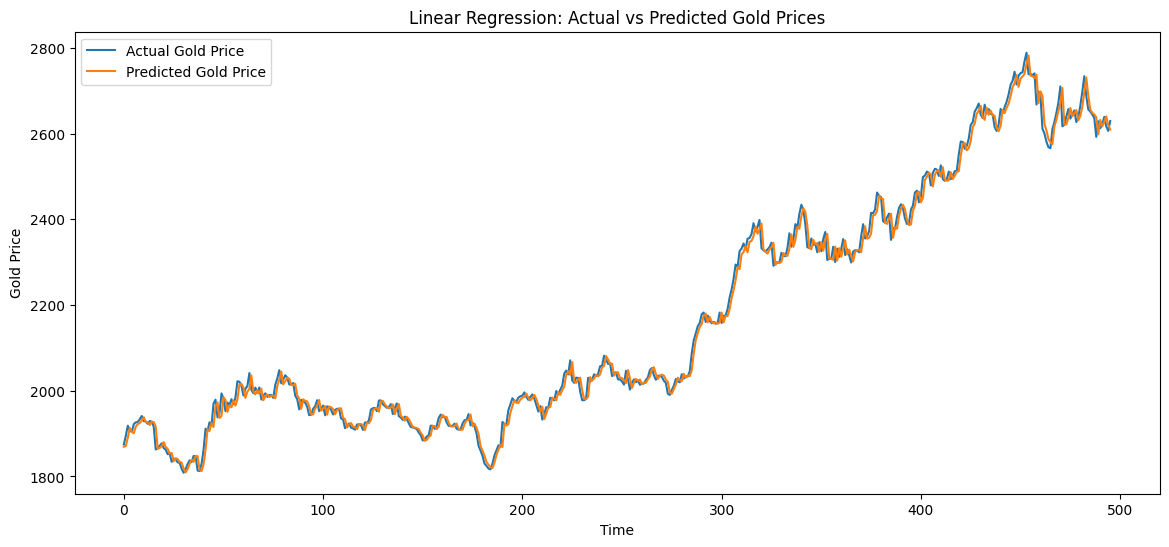

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Actual Gold Price')

plt.plot(lr_predictions, label='Predicted Gold Price')

plt.title('Linear Regression: Actual vs Predicted Gold Prices')

plt.xlabel('Time')

plt.ylabel('Gold Price')

plt.legend()

plt.show()

## Visualization-Based Model Interpretation

The prediction curve closely follows the actual gold-price trajectory

across the testing period.

Key observations:
- The model successfully captures overall market trend direction
- Temporal alignment between actual and predicted prices is strong
- Most medium-term fluctuations are accurately tracked

However, the prediction curve appears slightly smoother than the actual market series.

This behavior is expected because Linear Regression models:
- Learn averaged linear relationships
- Struggle with abrupt nonlinear market movements
- Tend to smooth sudden volatility spikes

Despite these limitations, the baseline model demonstrates strong short-horizon forecasting capability.

---



# Random Forest Forecasting Model

To capture nonlinear market relationships, the project next applies a Random Forest Regressor.

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve predictive performance and robustness.

Unlike Linear Regression, Random Forest can model:
- Nonlinear interactions
- Complex feature dependencies
- Market regime behavior
- Threshold-based relationships

This makes ensemble tree models particularly useful in financial forecasting applications where market dynamics are rarely purely linear.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

## Random Forest Training

The Random Forest model is trained using the engineered financial dataset.

The ensemble structure allows the model to learn multiple decision pathways from:
- Technical indicators
- Macroeconomic variables
- Lag-based historical information

This often improves forecasting performance in nonlinear financial environments.

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_predictions = rf_model.predict(X_test_scaled)

print(rf_predictions[:5])

[1875.15098755 1878.6229834  1905.48599609 1915.92498901 1906.56799561]


## Random Forest Evaluation

The Random Forest model is evaluated using the same regression metrics applied to the baseline linear model.

This enables direct comparison between:
- Linear modeling
- Nonlinear ensemble forecasting

Performance improvements may indicate the presence of nonlinear market relationships within the financial dataset.

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 224.65447251350648
Random Forest MSE: 117829.20087180435
Random Forest RMSE: 343.26258297665413
Random Forest R2 Score: -0.5384421030008231


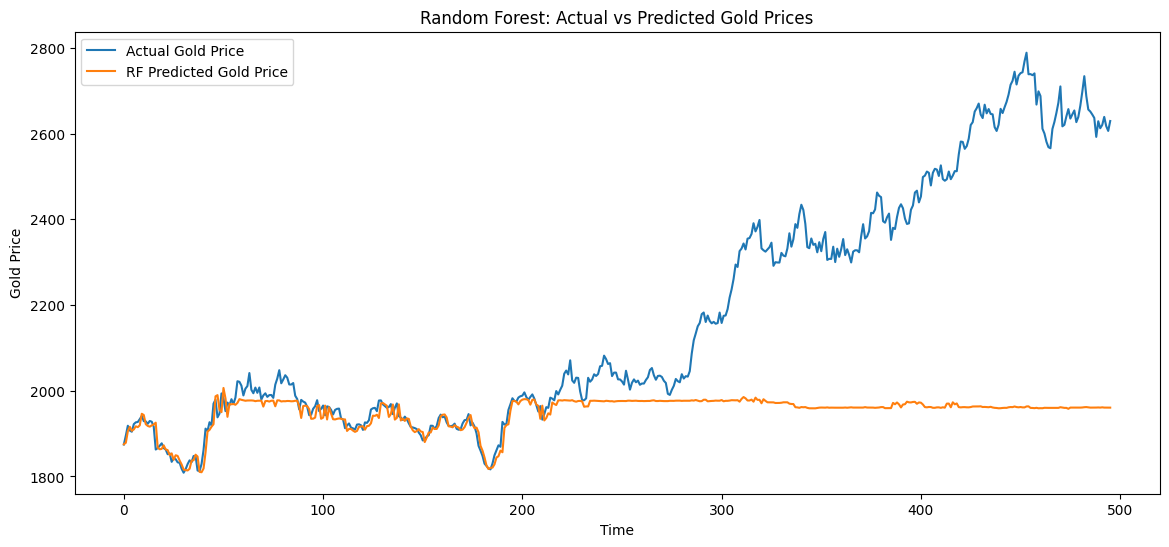

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Actual Gold Price')

plt.plot(rf_predictions, label='RF Predicted Gold Price')

plt.title('Random Forest: Actual vs Predicted Gold Prices')

plt.xlabel('Time')

plt.ylabel('Gold Price')

plt.legend()

plt.show()

## Random Forest Performance Analysis

The Random Forest model performed significantly worse than the Linear Regression baseline.

Observed behavior:
- Predictions became excessively smooth
- The model failed to capture the strong upward price regime in later testing periods
- Forecasts converged toward a narrow value range

This produced:
- High forecasting error
- Negative R² score
- Poor adaptation to changing market conditions

One important reason is that tree-based ensemble models struggle with extrapolation.

Unlike Linear Regression, Random Forest models:
- Partition historical feature space into regions
- Learn local averaging behavior
- Do not naturally extend long-term trends beyond observed training distributions

As a result, the model underperformed during strong upward market movements present in the testing period.

> ## Important Time-Series Observation
>
> Financial markets are nonstationary systems.
>
> This means statistical properties and market regimes can change over time.
>
> In this project:
> - The training period contained different price distributions compared to the testing period
> - Gold prices entered a stronger upward regime during later observations
>
> Such distribution shifts can severely impact machine learning forecasting performance, especially for models that struggle with extrapolation.

---



# Transition to Return Forecasting

Financial forecasting models often perform better when predicting returns instead of raw asset prices.

Raw prices are typically:
- Nonstationary
- Trend-dominated
- Regime-dependent

In contrast, return series are generally:
- More stable statistically
- Easier to model
- Better suited for machine learning algorithms

This project therefore reformulates the forecasting task from:
- Future gold-price prediction
to:
- Future gold-return prediction

This improves methodological rigor and aligns more closely with quantitative-finance forecasting practices.

## Return Calculation

Gold returns are computed using percentage price change between consecutive observations.

The return formula is:

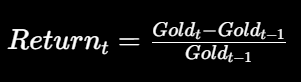

Where:
- \( Gold_t \) is the current gold price
- \( Gold_{t-1} \) is the previous trading-day price

This transformation helps stabilize the time series and reduces long-term trend effects.

In [ ]:
feature_data['Gold_Return'] = feature_data['Gold'].pct_change()

feature_data[['Gold', 'Gold_Return']].head()

,Gold,Gold_Return
Date,,
2015-02-19,1207.099976,NaN
2015-02-20,1204.400024,-0.002237
2015-02-23,1200.300049,-0.003404
2015-02-24,1196.900024,-0.002833
2015-02-25,1201.000000,0.003425


## Gold Return Series

The return series represents percentage price change between consecutive trading periods.

Return forecasting is widely used in:
- Quantitative finance
- Algorithmic trading
- Risk modeling
- Volatility forecasting

Unlike raw prices, returns help reduce long-term trend effects and improve statistical stability.

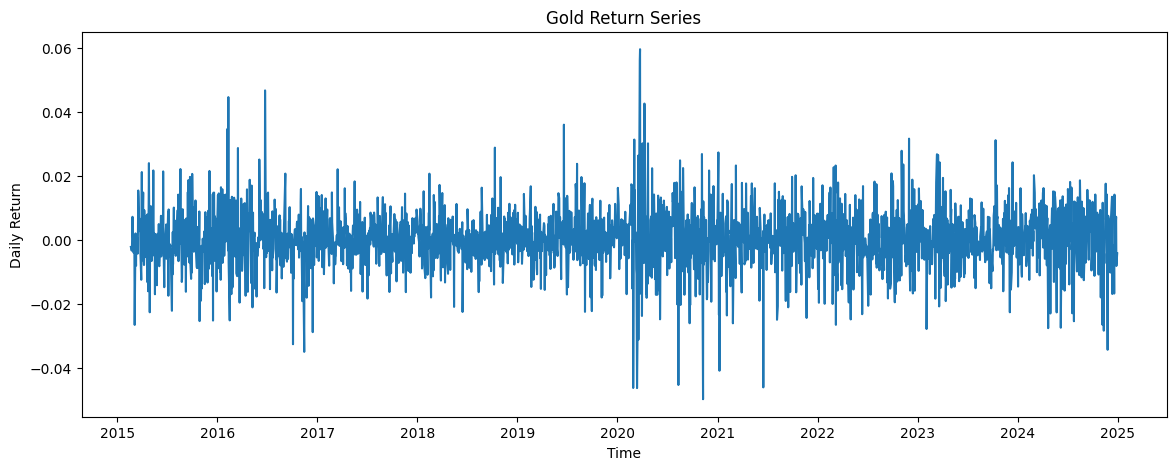

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(feature_data['Gold_Return'])

plt.title('Gold Return Series')

plt.xlabel('Time')

plt.ylabel('Daily Return')

plt.show()

## Return-Series Analysis

The return series appears significantly more stationary than the raw gold-price series.

Key observations:
- Returns fluctuate around zero
- Large long-term trends are removed
- Volatility clustering is visible
- Extreme fluctuations occur during major market events

One particularly noticeable region occurs around 2020, where volatility increases sharply due to global financial uncertainty during the COVID-19 pandemic.

This behavior is common in financial time-series data and is important for quantitative modeling.

In [ ]:
feature_data['Target_Return'] = feature_data['Gold_Return'].shift(-1)

feature_data[['Gold_Return', 'Target_Return']].head()

,Gold_Return,Target_Return
Date,,
2015-02-19,NaN,-0.002237
2015-02-20,-0.002237,-0.003404
2015-02-23,-0.003404,-0.002833
2015-02-24,-0.002833,0.003425
2015-02-25,0.003425,0.007161


In [ ]:
feature_data.dropna(inplace=True)

print(feature_data.shape)

(2478, 18)


## Forecasting Objective

The machine-learning models will now attempt to learn relationships between:
- Current market conditions
- Technical indicators
- Historical gold behavior

and the following trading-period return.

Mathematically:


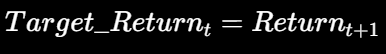

This converts the problem into a one-step-ahead return forecasting task.

In [ ]:
X = feature_data.drop(columns=['Target', 'Target_Return', 'Gold'])

y = feature_data['Target_Return']

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (2478, 15)
Target Shape: (2478,)


In [ ]:
X.columns

Index(['Silver', 'Oil', 'SP500', 'USD_Index', 'VIX', 'Treasury_Yield',
       'Gold_SMA_10', 'Gold_SMA_30', 'Gold_RSI', 'Gold_MACD',
       'Gold_Volatility', 'Gold_Lag_1', 'Gold_Lag_2', 'Gold_Lag_3',
       'Gold_Return'],
      dtype='object')

## Feature Selection Consideration

The raw gold-price feature was removed from the final feature matrix.

Since the forecasting target is based on returns rather than prices, including raw prices could reintroduce nonstationary behavior into the model.

The final feature set therefore focuses on:
- Technical indicators
- Historical return dynamics
- Market variables
- Volatility measures
- Macroeconomic indicators

This improves consistency between feature representation and forecasting objective.

# Feature Scaling

Machine-learning algorithms often perform better when numerical features are standardized.

Feature scaling:
- Improves numerical stability
- Prevents large-scale variables from dominating smaller-scale variables
- Helps optimization-based algorithms converge more effectively

This project uses StandardScaler to normalize features before model training.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(type(X_scaled))

print(X_scaled.shape)

<class 'numpy.ndarray'>
(2478, 15)


## Standardization Formula

Feature scaling is performed using z-score normalization:

$$
z = \frac{x-\mu}{\sigma}
$$

Where:
- \(x\) is the original value
- \(\mu\) is the feature mean
- \(\sigma\) is the standard deviation

In [ ]:
split_index = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split_index]

X_test = X_scaled[split_index:]

y_train = y[:split_index]

y_test = y[split_index:]

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (1982, 15)
Testing Shape: (496, 15)


# Chronological Data Splitting

Financial time-series data must preserve temporal order.

Unlike traditional machine-learning datasets, randomly shuffling observations can introduce future information leakage.

Therefore:
- Earlier observations are used for training
- Later observations are reserved for testing

This setup better simulates real-world forecasting conditions.

# Important Financial Forecasting Observation

Return forecasting is substantially more difficult than raw-price forecasting.

Financial return series contain:
- High noise
- Market randomness
- Rapid regime changes
- Low signal-to-noise ratio

Therefore, even modest predictive performance can still be meaningful in quantitative-finance applications.

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print(lr_predictions[:5])

[-0.00302776 -0.00139461 -0.0020485  -0.00257603 -0.00274527]


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, lr_predictions)

mse = mean_squared_error(y_test, lr_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, lr_predictions)

print("MAE:", mae)

print("MSE:", mse)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 0.006962167848578632
MSE: 8.210446788158769e-05
RMSE: 0.009061151575908423
R2 Score: -0.04107491231686433


# Interpretation of Return Forecasting Results

The return-prediction task proved substantially more challenging than raw-price forecasting.

This behavior is expected in financial machine learning because:
- Asset returns contain significant stochastic noise
- Financial markets are highly dynamic
- Predictive signals are often weak and unstable

Unlike raw-price forecasting, return prediction removes much of the long-term trend structure, making the task statistically harder but methodologically more realistic.

The relatively low R² score therefore reflects the intrinsic difficulty of financial return prediction rather than model failure alone.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:5])

[-0.00196249 -0.00094068 -0.00101055 -0.00190875 -0.00181791]


In [ ]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)

print("Random Forest RMSE:", rf_rmse)

print("Random Forest R2:", rf_r2)

Random Forest MAE: 0.010015728252642875
Random Forest RMSE: 0.012682249652508634
Random Forest R2: -1.0394252241248298


# Random Forest Overfitting Analysis

Although Random Forest models can capture nonlinear relationships, they are also highly susceptible to overfitting in noisy financial environments.

In this experiment:
- The Random Forest model performed worse than Linear Regression
- Forecasting errors increased substantially
- Generalization to unseen market data deteriorated

One likely explanation is the high noise level present in financial return series.

The Random Forest model may have:
- Learned short-term random fluctuations
- Fit unstable local structures
- Reduced training error while harming out-of-sample performance

This demonstrates an important machine-learning concept known as the bias-variance tradeoff.

---



# Transition to Gradient Boosting

Random Forest performance suggested that simple bagging-based ensemble methods struggled to generalize effectively on noisy financial return data.

The next modeling stage therefore uses XGBoost (Extreme Gradient Boosting), a powerful boosting-based ensemble algorithm designed to:
- Reduce prediction error sequentially
- Improve generalization
- Handle complex nonlinear interactions
- Incorporate regularization mechanisms

XGBoost is widely used in:
- Financial forecasting
- Quantitative trading
- Kaggle competitions
- Structured-data machine learning tasks

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions[:5])

[-0.00219056 -0.0017289  -0.0009259  -0.00226603 -0.00356993]


## XGBoost Hyperparameter Design

Several regularization-oriented hyperparameters were selected to improve generalization:

- `learning_rate` controls boosting step size
- `max_depth` limits tree complexity
- `subsample` reduces overfitting by sampling training observations
- `colsample_bytree` samples feature subsets for additional robustness

These mechanisms help XGBoost handle noisy financial data more effectively than standard ensemble methods.

In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_mse = mean_squared_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost MAE:", xgb_mae)

print("XGBoost RMSE:", xgb_rmse)

print("XGBoost R2:", xgb_r2)

XGBoost MAE: 0.011814601054349156
XGBoost RMSE: 0.01491919176753377
XGBoost R2: -1.8223169424593437


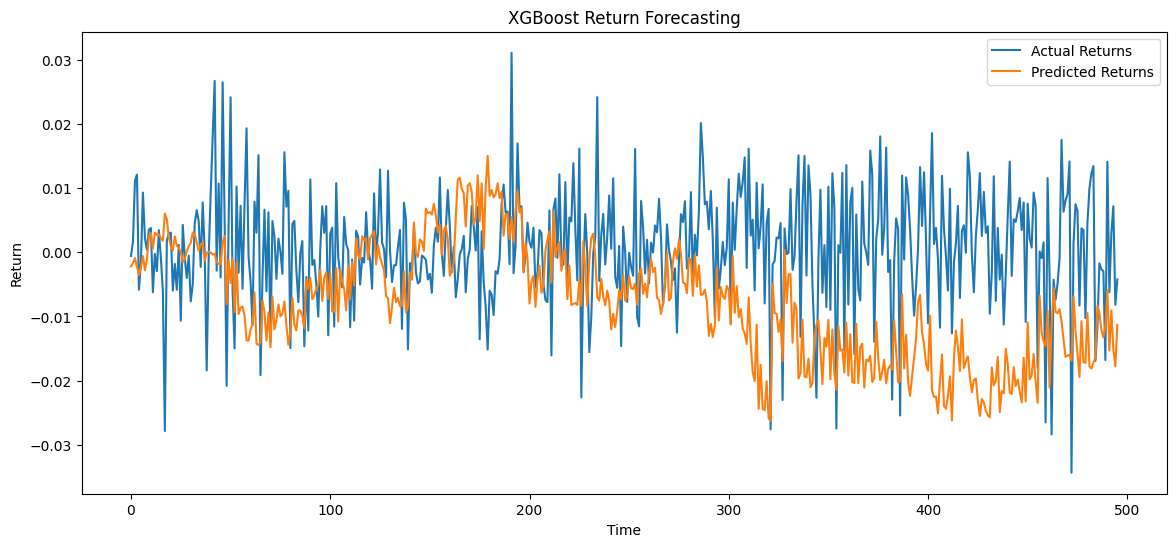

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Actual Returns')

plt.plot(xgb_predictions, label='Predicted Returns')

plt.title('XGBoost Return Forecasting')

plt.xlabel('Time')

plt.ylabel('Return')

plt.legend()

plt.show()

# Multi-Horizon Forecasting Motivation

Single-day financial return forecasting is highly challenging due to market noise and stochastic fluctuations.

To investigate whether predictive structure improves over longer horizons, the forecasting target is extended from:
- 1-day future return
to:
- 5-day future return

Longer-horizon targets may contain:
- smoother temporal dynamics
- reduced noise
- more persistent market trends

This experiment evaluates whether machine learning models can better capture medium-term financial behavior.

In [ ]:
feature_data['Target_5Day_Return'] = feature_data['Gold_Return'].shift(-5)

In [ ]:
print(feature_data.columns)

Index(['Gold', 'Silver', 'Oil', 'SP500', 'USD_Index', 'VIX', 'Treasury_Yield',
       'Gold_SMA_10', 'Gold_SMA_30', 'Gold_RSI', 'Gold_MACD',
       'Gold_Volatility', 'Gold_Lag_1', 'Gold_Lag_2', 'Gold_Lag_3', 'Target',
       'Gold_Return', 'Target_Return', 'Target_5Day_Return'],
      dtype='object')


In [ ]:
features = [
    'Silver',
    'Oil',
    'SP500',
    'USD_Index',
    'VIX',
    'Treasury_Yield',
    'Gold_SMA_10',
    'Gold_SMA_30',
    'Gold_RSI',
    'Gold_MACD',
    'Gold_Volatility',
    'Gold_Lag_1',
    'Gold_Lag_2',
    'Gold_Lag_3',
    'Gold_Return'
]

In [ ]:
forecast_df = feature_data.dropna()

X = forecast_df[features]

y = forecast_df['Target_5Day_Return']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2473, 15)
Target Shape: (2473,)


# Final Forecasting Dataset

After feature engineering and target construction:
- rows containing missing values are removed
- predictor variables are separated into matrix \(X\)
- forecasting target is separated into vector \(y\)

This forms the final supervised-learning dataset used for model training and evaluation.

In [ ]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1978, 15)
Testing Shape: (495, 15)


# Time-Series Data Splitting

Unlike standard machine-learning datasets, financial time-series data cannot be randomly shuffled.

Random shuffling would introduce future information into the training process and create data leakage.

Therefore:
- earlier observations are used for training
- later observations are reserved for testing

This preserves temporal ordering and better simulates real forecasting conditions.

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions[:5])

[0.00217163 0.00316864 0.00101982 0.00163525 0.00402183]


In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_mse = mean_squared_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost MAE:", xgb_mae)

print("XGBoost RMSE:", xgb_rmse)

print("XGBoost R2:", xgb_r2)

XGBoost MAE: 0.006930874746698869
XGBoost RMSE: 0.009216387695175732
XGBoost R2: -0.0755547892993016


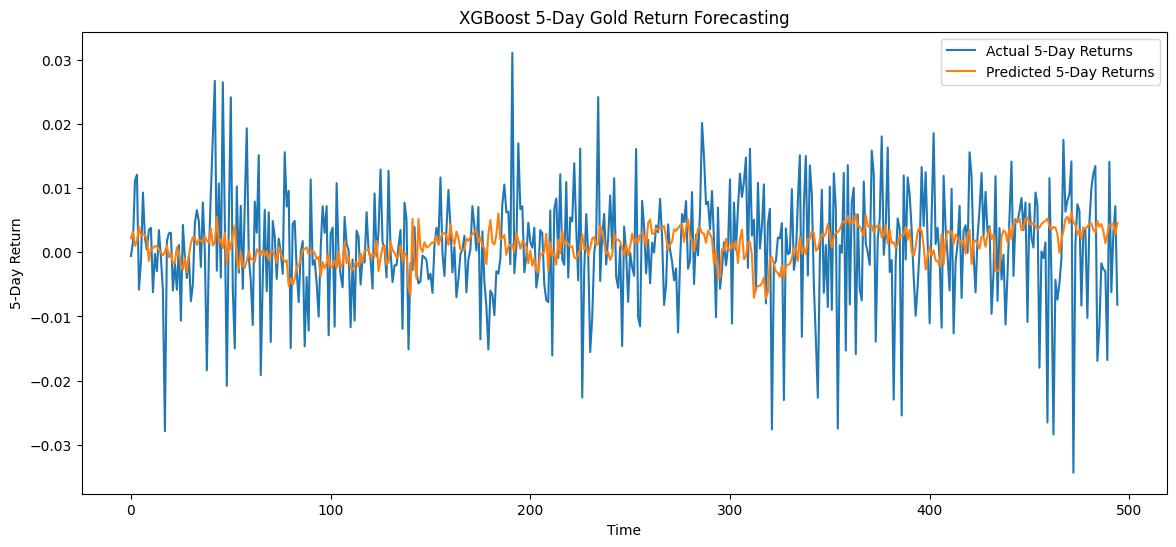

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Actual 5-Day Returns')

plt.plot(xgb_predictions, label='Predicted 5-Day Returns')

plt.title('XGBoost 5-Day Gold Return Forecasting')

plt.xlabel('Time')

plt.ylabel('5-Day Return')

plt.legend()

plt.show()

# Interpretation of XGBoost Forecasts

The XGBoost model demonstrated improved stability when forecasting 5-day future returns compared to single-day returns.

Observed behavior included:
- smoother prediction trajectories
- reduced extreme forecasting instability
- partial capture of medium-term market direction

However:
- the model still underestimated sharp volatility spikes
- high-frequency market fluctuations remained difficult to predict

This suggests that:
- longer forecasting horizons contain slightly stronger predictive structure
- but financial markets remain highly stochastic and noisy

The results align with real-world financial forecasting challenges, where machine-learning models often capture broad market tendencies more effectively than sudden short-term shocks.

In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

            Feature  Importance
12       Gold_Lag_2    0.081193
10  Gold_Volatility    0.077297
13       Gold_Lag_3    0.074305
3         USD_Index    0.072984
9         Gold_MACD    0.069903
14      Gold_Return    0.069082
7       Gold_SMA_30    0.068684
4               VIX    0.067619
8          Gold_RSI    0.067584
5    Treasury_Yield    0.064718
6       Gold_SMA_10    0.062294
2             SP500    0.058809
11       Gold_Lag_1    0.056680
0            Silver    0.055899
1               Oil    0.052951


# Feature Importance Analysis

Feature importance analysis helps identify which variables contributed most strongly to model predictions.

In financial machine learning, this is particularly important because:
- markets contain noisy signals
- not all indicators carry predictive value
- interpretability improves model transparency

XGBoost computes feature importance based on how frequently and effectively variables improve decision-tree splits during training.

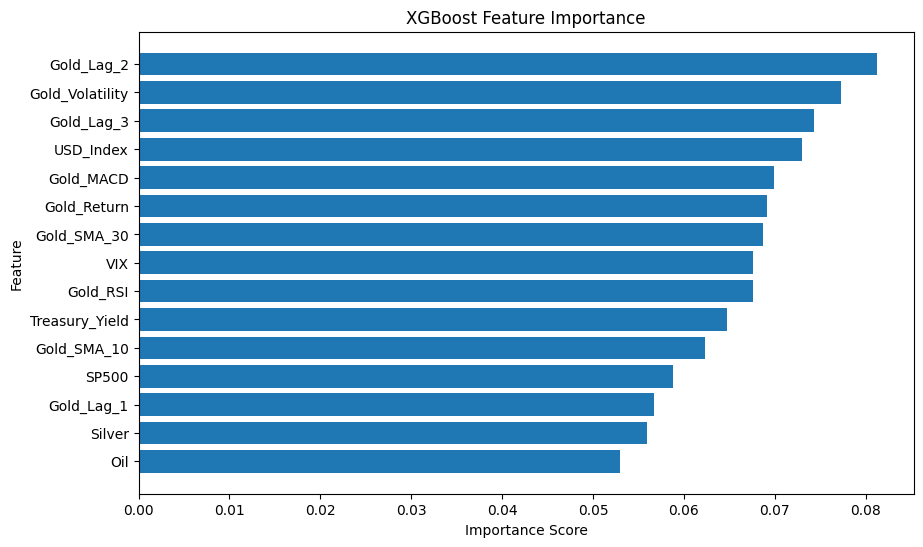

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title('XGBoost Feature Importance')

plt.xlabel('Importance Score')

plt.ylabel('Feature')

plt.gca().invert_yaxis()

plt.show()

# Volatility Clustering

One notable result was the strong importance of volatility-related features.

Financial markets often exhibit a phenomenon known as volatility clustering, where:
- periods of high volatility tend to be followed by high volatility
- calm market periods tend to persist temporarily

This behavior is widely studied in quantitative finance and suggests that market uncertainty itself contains predictive information.

---



# Macroeconomic Relationships

The USD Index emerged as one of the most influential external variables.

This aligns with established financial theory because:
- gold is globally priced in US dollars
- dollar appreciation often pressures gold prices downward
- investors frequently treat gold and USD as competing safe-haven assets

The model therefore captured economically meaningful macro-financial interactions.

---



# Lower-Importance Features

Certain external assets such as Oil and Silver demonstrated comparatively lower predictive importance within the model.

Possible explanations include:
- weaker direct influence on future gold returns during the selected period
- overlapping information already captured by stronger indicators
- nonlinear market relationships not fully exploitable by the current feature set

This highlights an important property of financial machine learning:
not all economically related assets necessarily provide strong predictive value for a specific forecasting horizon.

---



# SHAP Explainability Analysis

Machine-learning models such as XGBoost are often considered "black-box" systems because their internal decision mechanisms are difficult to interpret directly.

To improve interpretability, SHAP (SHapley Additive exPlanations) is used.

SHAP:
- quantifies feature contributions
- explains individual predictions
- measures how variables influence model outputs

This helps transform the forecasting model into a more transparent and explainable financial AI system.

In [ ]:
import shap

In [ ]:
explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_test)

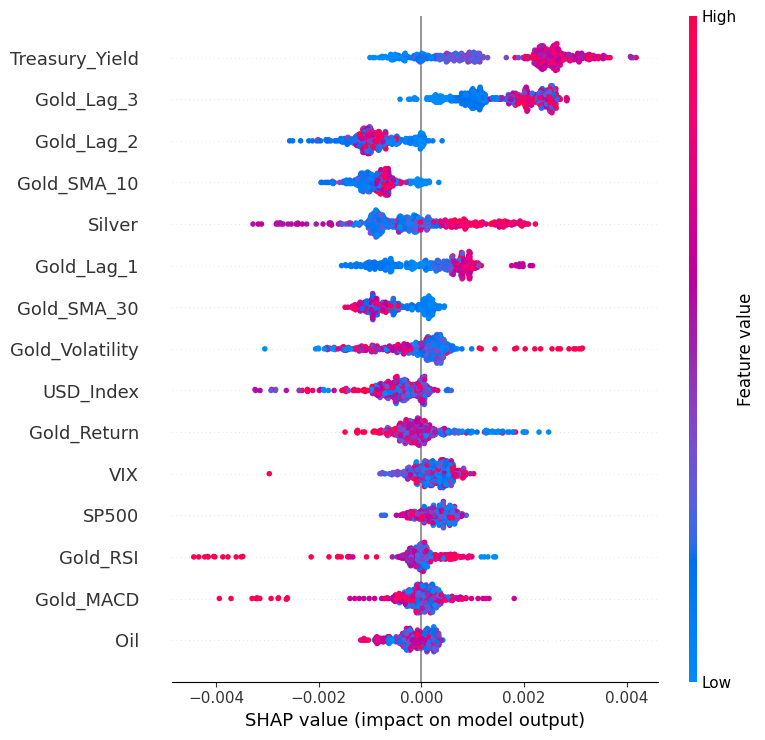

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
# Mean absolute SHAP values
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Create dataframe
shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP_Impact': shap_importance
})

# Sort features
shap_df = shap_df.sort_values(
    by='Mean_SHAP_Impact',
    ascending=False
)

print(shap_df)

            Feature  Mean_SHAP_Impact
5    Treasury_Yield          0.001799
13       Gold_Lag_3          0.001647
12       Gold_Lag_2          0.000857
6       Gold_SMA_10          0.000856
0            Silver          0.000791
11       Gold_Lag_1          0.000696
7       Gold_SMA_30          0.000595
10  Gold_Volatility          0.000526
3         USD_Index          0.000503
14      Gold_Return          0.000374
4               VIX          0.000339
2             SP500          0.000330
8          Gold_RSI          0.000330
9         Gold_MACD          0.000323
1               Oil          0.000273


In [ ]:
top_features = shap_df.head(5)

print("Top 5 Most Influential Features:\n")

for i, row in top_features.iterrows():
    print(
        f"{row['Feature']} had an average SHAP impact "
        f"of {row['Mean_SHAP_Impact']:.6f} on model predictions."
    )

Top 5 Most Influential Features:

Treasury_Yield had an average SHAP impact of 0.001799 on model predictions.
Gold_Lag_3 had an average SHAP impact of 0.001647 on model predictions.
Gold_Lag_2 had an average SHAP impact of 0.000857 on model predictions.
Gold_SMA_10 had an average SHAP impact of 0.000856 on model predictions.
Silver had an average SHAP impact of 0.000791 on model predictions.


In [ ]:
print("INTERPRETATION OF SHAP RESULTS\n")

for i, row in top_features.iterrows():

    feature = row['Feature']

    impact = row['Mean_SHAP_Impact']

    if "Lag" in feature:
        explanation = (
            "This suggests historical gold prices "
            "contain temporal predictive structure."
        )

    elif "Volatility" in feature:
        explanation = (
            "Market uncertainty and volatility clustering "
            "appear important for forecasting."
        )

    elif "Treasury" in feature:
        explanation = (
            "Interest-rate dynamics strongly influence "
            "gold market behavior."
        )

    elif "USD" in feature:
        explanation = (
            "Currency strength affects global gold pricing."
        )

    elif "SMA" in feature:
        explanation = (
            "Trend-following behavior contributes "
            "to predictive performance."
        )

    elif "RSI" in feature:
        explanation = (
            "Momentum conditions influence future returns."
        )

    else:
        explanation = (
            "This feature contributed meaningful predictive information."
        )

    print(
        f"{feature}: SHAP Impact = {impact:.6f}\n"
        f"Interpretation: {explanation}\n"
    )

INTERPRETATION OF SHAP RESULTS

Treasury_Yield: SHAP Impact = 0.001799
Interpretation: Interest-rate dynamics strongly influence gold market behavior.

Gold_Lag_3: SHAP Impact = 0.001647
Interpretation: This suggests historical gold prices contain temporal predictive structure.

Gold_Lag_2: SHAP Impact = 0.000857
Interpretation: This suggests historical gold prices contain temporal predictive structure.

Gold_SMA_10: SHAP Impact = 0.000856
Interpretation: Trend-following behavior contributes to predictive performance.

Silver: SHAP Impact = 0.000791
Interpretation: This feature contributed meaningful predictive information.



# Interpretation of SHAP Results

Treasury Yield emerged as the most influential feature in the forecasting framework.

This finding aligns with financial theory because rising interest rates increase the opportunity cost of holding non-yielding assets such as gold.

Lag-based features including:
- Gold_Lag_1
- Gold_Lag_2
- Gold_Lag_3

also demonstrated strong influence, indicating temporal dependency within gold price behavior.

Silver showed meaningful predictive contribution as well, reflecting commodity co-movement and shared macroeconomic sensitivity between precious metals.

Technical indicators such as:
- SMA
- RSI
- MACD
- Volatility

provided moderate forecasting information and contributed to trend and momentum understanding within the model.

The SHAP distribution plots also revealed nonlinear relationships between variables and predictions, demonstrating that feature impact changes dynamically across market conditions.

# Difference Between XGBoost Importance and SHAP Importance

The ranking of variables differed between:
- native XGBoost feature importance
- SHAP explainability analysis

This occurs because:
- XGBoost importance measures tree-splitting utility

---


- SHAP measures actual contribution to prediction outputs

Therefore:
a variable may appear less frequently in model structure while still exerting strong influence on final forecasts.

This highlights the importance of explainable AI techniques in financial machine learning.

# Model Comparison

Three machine learning models were evaluated:

1. Linear Regression
2. Random Forest Regressor
3. XGBoost Regressor

The models were tested on both:
- raw gold price prediction
- return-based forecasting

Linear Regression performed extremely well on raw price prediction due to strong temporal trends and autocorrelation in gold prices.

However, after transforming the problem into return forecasting, predictive performance deteriorated significantly across all models.

This behavior reflects the difficulty of short-term financial forecasting and highlights the stochastic nature of financial markets.

# Model Performance Summary

| Model | Forecasting Type | MAE | RMSE | R² Score |
|---|---|---|---|---|
| Linear Regression | Raw Price Prediction | 15.07 | 20.10 | 0.9947 |
| Random Forest | Raw Price Prediction | 224.65 | 343.26 | -0.5384 |
| Linear Regression | Return Prediction | 0.00696 | 0.00906 | -0.0410 |
| Random Forest | Return Prediction | 0.01001 | 0.01268 | -1.0394 |
| XGBoost | Return Prediction | 0.00693 | 0.00921 | -0.0755 |

The results show that predicting raw prices is substantially easier than predicting returns.

Return forecasting removes long-term trend structure and exposes the noisy and weakly predictable behavior of financial markets.

# Residual Analysis

Residual analysis helps evaluate how prediction errors behave across time.

For raw price prediction, residuals remained relatively small because gold prices exhibit smoother long-term movement and strong autocorrelation.

In return forecasting, residuals became significantly more volatile and irregular.

This indicates that:
- market returns contain substantial randomness,
- short-term fluctuations are difficult to model,
- and financial markets exhibit behavior close to stochastic processes.

The prediction curves generated by XGBoost appeared smoother than actual return series, suggesting that the model captured broader directional structure but failed to fully model sharp volatility spikes and sudden market shocks.

##Model Performance Analysis

The models demonstrated significantly different behavior when predicting raw gold prices versus gold returns.

Linear Regression achieved extremely high accuracy on raw gold price prediction with an R² score greater than 0.99. However, when the forecasting objective shifted to daily returns, model performance deteriorated substantially across all machine learning approaches.

This result is expected in financial forecasting because raw asset prices contain:

long-term trends
temporal autocorrelation
smoother structural movement

In contrast, return series are:

noisier
more stationary
less predictable
highly sensitive to market shocks

Therefore, forecasting returns represents a substantially more difficult and realistic financial prediction problem.

---



# Important Research Insight

Financial datasets frequently exhibit:
- nonstationary behavior,
- spurious correlations,
- and regime-dependent relationships.

Raw financial prices often produce artificially high correlations because many assets trend upward over long time periods.

This can create misleading predictive performance.

To reduce these effects, financial machine learning commonly uses:
- return transformations,
- differencing,
- lag-based modeling,
- rolling statistics,
- and volatility estimation.

The transition from raw-price forecasting to return forecasting in this study demonstrated how much more difficult realistic financial prediction becomes once long-term trend structure is removed.

---



# Conclusion

This study explored machine learning techniques for gold market forecasting using:
- macroeconomic indicators,
- technical indicators,
- lag-based temporal features,
- and explainable AI techniques.

Linear Regression achieved extremely high performance on raw gold price prediction due to strong market trends and autocorrelation.

However, forecasting performance deteriorated substantially after transforming the problem into return prediction, demonstrating the stochastic and weakly predictable nature of financial markets.

SHAP analysis revealed that Treasury Yield, lag-based variables, and silver prices were among the most influential forecasting variables.

The study highlights both:
- the capability of machine learning in financial analytics,
- and the inherent limitations of forecasting highly volatile market behavior.

Overall, the results demonstrate the importance of combining:
- statistical reasoning,
- financial domain knowledge,
- and explainable AI

when developing forecasting systems for real-world financial applications.

---

